In [ ]:
# SBERT probabilistic classifier

XGBoost Probabilistic Classifier for Vulnerability Detection
Using SBERT (Sentence-BERT) Embeddings
Loading data...
Found 768 embedding dimensions

Class distribution:
  Class 0: 7207 (42.39%)
  Class 1: 9794 (57.61%)

Data split:
  Training:   11906 samples
  Validation: 2544 samples
  Test:       2551 samples

Training XGBoost classifier...
Using scale_pos_weight: 0.74
[0]	validation_0-logloss:0.68497	validation_1-logloss:0.68558
[50]	validation_0-logloss:0.53029	validation_1-logloss:0.58219
[100]	validation_0-logloss:0.43334	validation_1-logloss:0.56111
[150]	validation_0-logloss:0.34681	validation_1-logloss:0.55053
[200]	validation_0-logloss:0.28402	validation_1-logloss:0.54259
[250]	validation_0-logloss:0.23729	validation_1-logloss:0.54002
[299]	validation_0-logloss:0.20175	validation_1-logloss:0.53862

Training completed with early stopping
Best iteration: N/A
Training complete!

Calibrating probabilities using isotonic regression...
Calibration complete!

EVALUATION ON TEST SET


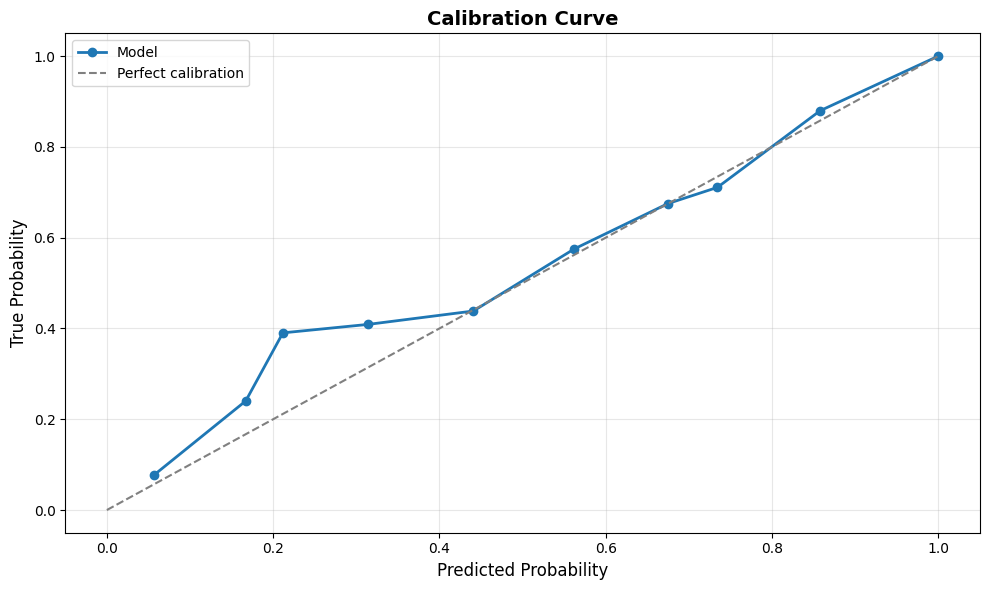

ROC curve saved to roc_curve.png


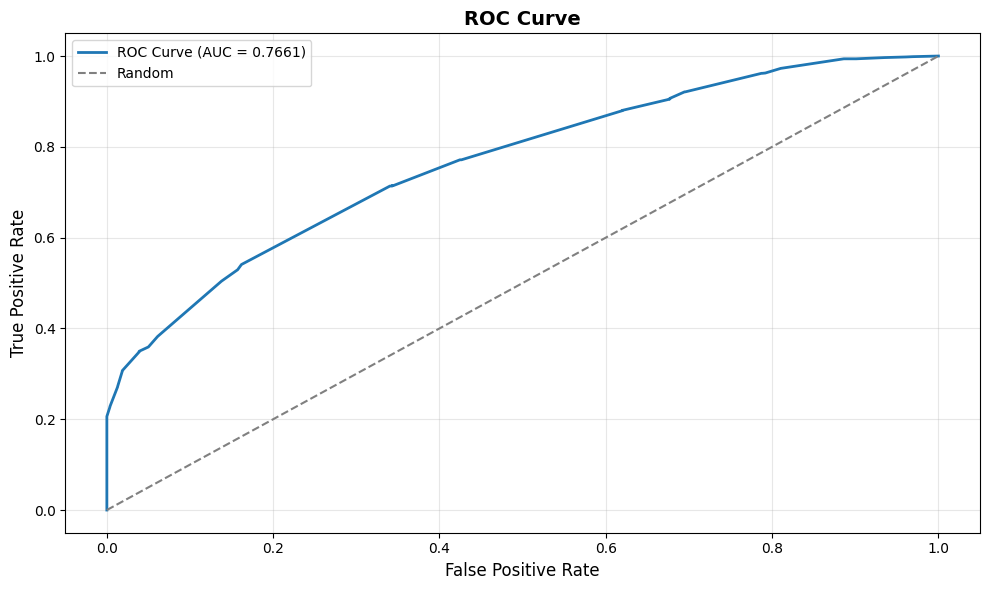

PR curve saved to pr_curve.png


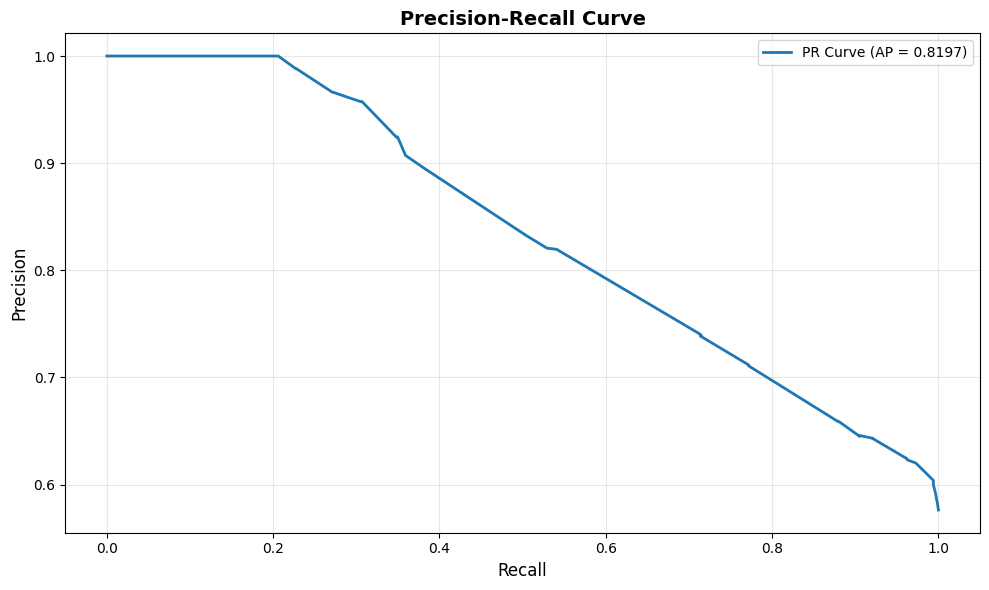

Probability distribution plot saved to prob_distribution.png


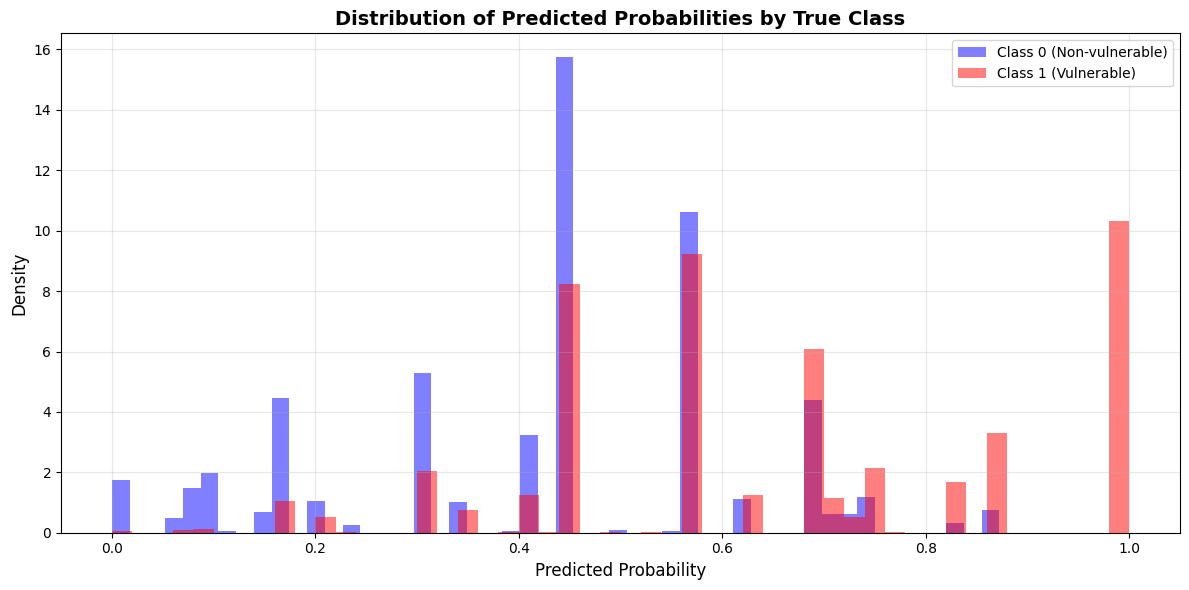


TOP 20 MOST IMPORTANT FEATURES
feature  importance
dim_367    0.014113
dim_368    0.013274
dim_282    0.012960
dim_555    0.007248
dim_628    0.005554
dim_414    0.005450
dim_187    0.004983
dim_598    0.004238
dim_107    0.004052
dim_670    0.003912
dim_576    0.003849
 dim_34    0.003548
 dim_42    0.003263
dim_421    0.002671
dim_249    0.002583
dim_466    0.002397
dim_320    0.002348
dim_551    0.002318
dim_606    0.002300
dim_193    0.002294

Feature importance plot saved to feature_importance.png


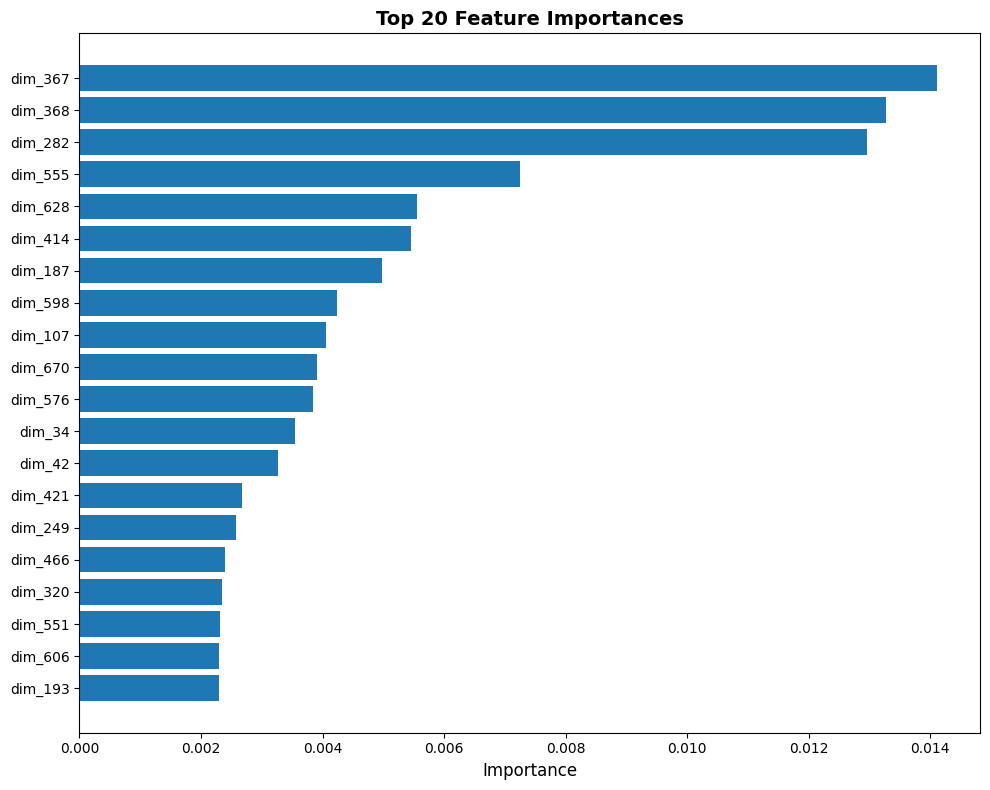


TRAINING COMPLETE!

Model is ready for predictions. Use:
  - clf.predict_proba(X) for probability estimates
  - clf.predict(X, threshold=0.5) for class predictions
✓ SBERT model saved as clf_sbert


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, log_loss, brier_score_loss,
    average_precision_score
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

class VulnerabilityClassifier:
    
    def __init__(self, calibrate=True):
       
        self.calibrate = calibrate
        self.model = None
        self.calibrated_model = None
        self.feature_cols = None
        
    def load_data(self, filepath):
       
        print("Loading data...")
        df = pd.read_csv(filepath)
        
        
        self.feature_cols = [col for col in df.columns if col.startswith('dim_')]
        print(f"Found {len(self.feature_cols)} embedding dimensions")
        
        X = df[self.feature_cols].values
        y = df['target'].values
        
        
        unique, counts = np.unique(y, return_counts=True)
        print(f"\nClass distribution:")
        for label, count in zip(unique, counts):
            print(f"  Class {label}: {count} ({count/len(y)*100:.2f}%)")
        
        return X, y, df
    
    def train(self, X_train, y_train, X_val=None, y_val=None):
       
        print("\nTraining XGBoost classifier...")
        
        
        unique, counts = np.unique(y_train, return_counts=True)
        if len(unique) == 2:
            scale_pos_weight = counts[0] / counts[1]
            print(f"Using scale_pos_weight: {scale_pos_weight:.2f}")
        else:
            scale_pos_weight = 1
        
        
        params = {
            'objective': 'binary:logistic',  
            'eval_metric': 'logloss',        
            'max_depth': 6,                   
            'learning_rate': 0.05,            
            'n_estimators': 300,              
            'min_child_weight': 3,            
            'subsample': 0.8,                 
            'colsample_bytree': 0.8,          
            'reg_alpha': 0.1,                 
            'reg_lambda': 1.0,                
            'scale_pos_weight': scale_pos_weight,  
            'random_state': RANDOM_STATE,
            'n_jobs': -1,                     
            'tree_method': 'hist',           
        }
        
       
        self.model = xgb.XGBClassifier(**params)
        
        
        eval_set = [(X_train, y_train)]
        if X_val is not None and y_val is not None:
            eval_set.append((X_val, y_val))

        try:
           
            from xgboost.callback import EarlyStopping
            callbacks = [EarlyStopping(rounds=50, save_best=True)]
            
            self.model.fit(
                X_train, y_train,
                eval_set=eval_set,
                callbacks=callbacks,
                verbose=50
            )
        except (ImportError, TypeError):
        
            try:
                self.model.fit(
                    X_train, y_train,
                    eval_set=eval_set,
                    early_stopping_rounds=50,
                    verbose=50
                )
            except TypeError:
              
                print("Warning: Early stopping not available, training without it")
                self.model.fit(
                    X_train, y_train,
                    eval_set=eval_set,
                    verbose=50
                )
        
        print(f"\nTraining completed with early stopping")
        print(f"Best iteration: {self.model.best_iteration if hasattr(self.model, 'best_iteration') else 'N/A'}")
        print(f"Training complete!")
        
       
        if self.calibrate:
            print("\nCalibrating probabilities using isotonic regression...")
            self.calibrated_model = CalibratedClassifierCV(
                self.model, 
                method='isotonic',
                cv='prefit'  
            )
            self.calibrated_model.fit(X_val, y_val)
            print("Calibration complete!")
        
        return self
    
    def predict_proba(self, X, use_calibrated=None):
        
        if use_calibrated is None:
            use_calibrated = self.calibrate
        
        if use_calibrated and self.calibrated_model is not None:
            return self.calibrated_model.predict_proba(X)[:, 1]
        else:
            return self.model.predict_proba(X)[:, 1]
    
    def predict(self, X, threshold=0.5, use_calibrated=None):
       
        probs = self.predict_proba(X, use_calibrated)
        return (probs >= threshold).astype(int)
    
    def evaluate(self, X, y, use_calibrated=None, threshold=0.5):
        
        print("\n" + "="*80)
        print("MODEL EVALUATION")
        print("="*80)
        
        
        y_probs = self.predict_proba(X, use_calibrated)
        y_pred = (y_probs >= threshold).astype(int)
        
        
        print("\nClassification Report:")
        print(classification_report(y, y_pred, digits=4))
        
        
        print("\nProbability Quality Metrics:")
        print(f"  Log Loss (lower is better):    {log_loss(y, y_probs):.4f}")
        print(f"  Brier Score (lower is better): {brier_score_loss(y, y_probs):.4f}")
        print(f"  ROC-AUC Score:                 {roc_auc_score(y, y_probs):.4f}")
        print(f"  Average Precision Score:       {average_precision_score(y, y_probs):.4f}")
        
        
        cm = confusion_matrix(y, y_pred)
        print("\nConfusion Matrix:")
        print(cm)
        
        return {
            'y_true': y,
            'y_pred': y_pred,
            'y_probs': y_probs,
            'log_loss': log_loss(y, y_probs),
            'brier_score': brier_score_loss(y, y_probs),
            'roc_auc': roc_auc_score(y, y_probs),
            'avg_precision': average_precision_score(y, y_probs)
        }
    
    def plot_calibration(self, X, y, use_calibrated=None, save_path=None):
        
        y_probs = self.predict_proba(X, use_calibrated)
        
        
        prob_true, prob_pred = calibration_curve(y, y_probs, n_bins=10, strategy='uniform')
        
        
        plt.figure(figsize=(10, 6))
        plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
        plt.xlabel('Predicted Probability', fontsize=12)
        plt.ylabel('True Probability', fontsize=12)
        plt.title('Calibration Curve', fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Calibration curve saved to {save_path}")
        plt.show()
    
    def plot_roc_curve(self, X, y, use_calibrated=None, save_path=None):
        
        y_probs = self.predict_proba(X, use_calibrated)
        fpr, tpr, thresholds = roc_curve(y, y_probs)
        auc_score = roc_auc_score(y, y_probs)
        
        plt.figure(figsize=(10, 6))
        plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
        plt.xlabel('False Positive Rate', fontsize=12)
        plt.ylabel('True Positive Rate', fontsize=12)
        plt.title('ROC Curve', fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"ROC curve saved to {save_path}")
        plt.show()
    
    def plot_precision_recall_curve(self, X, y, use_calibrated=None, save_path=None):
       
        y_probs = self.predict_proba(X, use_calibrated)
        precision, recall, thresholds = precision_recall_curve(y, y_probs)
        avg_precision = average_precision_score(y, y_probs)
        
        plt.figure(figsize=(10, 6))
        plt.plot(recall, precision, linewidth=2, 
                label=f'PR Curve (AP = {avg_precision:.4f})')
        plt.xlabel('Recall', fontsize=12)
        plt.ylabel('Precision', fontsize=12)
        plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"PR curve saved to {save_path}")
        plt.show()
    
    def plot_probability_distribution(self, X, y, use_calibrated=None, save_path=None):
        
        y_probs = self.predict_proba(X, use_calibrated)
        
        plt.figure(figsize=(12, 6))
        
       
        probs_class_0 = y_probs[y == 0]
        probs_class_1 = y_probs[y == 1]
        
        plt.hist(probs_class_0, bins=50, alpha=0.5, label='Class 0 (Non-vulnerable)', 
                color='blue', density=True)
        plt.hist(probs_class_1, bins=50, alpha=0.5, label='Class 1 (Vulnerable)', 
                color='red', density=True)
        
        plt.xlabel('Predicted Probability', fontsize=12)
        plt.ylabel('Density', fontsize=12)
        plt.title('Distribution of Predicted Probabilities by True Class', 
                 fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Probability distribution plot saved to {save_path}")
        plt.show()
    
    def find_optimal_threshold(self, X, y, metric='f1', use_calibrated=None):
       
        from sklearn.metrics import f1_score, precision_score, recall_score
        
        y_probs = self.predict_proba(X, use_calibrated)
        thresholds = np.linspace(0, 1, 101)
        scores = []
        
        for threshold in thresholds:
            y_pred = (y_probs >= threshold).astype(int)
            
            if metric == 'f1':
                score = f1_score(y, y_pred, zero_division=0)
            elif metric == 'precision':
                score = precision_score(y, y_pred, zero_division=0)
            elif metric == 'recall':
                score = recall_score(y, y_pred, zero_division=0)
            elif metric == 'youden':
                
                fpr, tpr, _ = roc_curve(y, y_probs)
                idx = np.argmin(np.abs(thresholds[0] - _))
                score = tpr[idx] - fpr[idx]
            else:
                raise ValueError(f"Unknown metric: {metric}")
            
            scores.append(score)
        
        optimal_idx = np.argmax(scores)
        optimal_threshold = thresholds[optimal_idx]
        
        print(f"\nOptimal threshold ({metric}): {optimal_threshold:.3f}")
        print(f"Score at optimal threshold: {scores[optimal_idx]:.4f}")
        
        return optimal_threshold


def main():
   
   
    filepath = r"M:\Merged\Application2\ExtractedForParsing\vul_fix_vul_jsonl\sbertembedding_chunks\merged_sbert_embedding_shifts_chunks_noTripleZero.csv"
    
    print("="*80)
    print("XGBoost Probabilistic Classifier for Vulnerability Detection")
    print("Using SBERT (Sentence-BERT) Embeddings")
    print("="*80)
    
    
    clf = VulnerabilityClassifier(calibrate=True)
    
    
    X, y, df = clf.load_data(filepath)
    
  
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.176, random_state=RANDOM_STATE, stratify=y_temp
    )
    
    print(f"\nData split:")
    print(f"  Training:   {len(X_train)} samples")
    print(f"  Validation: {len(X_val)} samples")
    print(f"  Test:       {len(X_test)} samples")
    
   
    clf.train(X_train, y_train, X_val, y_val)
    
    
    print("\n" + "="*80)
    print("EVALUATION ON TEST SET")
    print("="*80)
    
    
    print("\n--- WITHOUT CALIBRATION ---")
    results_uncalibrated = clf.evaluate(X_test, y_test, use_calibrated=False)
    
    if clf.calibrate:
        print("\n--- WITH CALIBRATION ---")
        results_calibrated = clf.evaluate(X_test, y_test, use_calibrated=True)
    
    
    optimal_threshold = clf.find_optimal_threshold(X_val, y_val, metric='f1')
    
   
    print("\n" + "="*80)
    print("GENERATING VISUALIZATIONS")
    print("="*80)
    
    clf.plot_calibration(X_test, y_test, save_path='calibration_curve.png')
    clf.plot_roc_curve(X_test, y_test, save_path='roc_curve.png')
    clf.plot_precision_recall_curve(X_test, y_test, save_path='pr_curve.png')
    clf.plot_probability_distribution(X_test, y_test, save_path='prob_distribution.png')
    
  
    print("\n" + "="*80)
    print("TOP 20 MOST IMPORTANT FEATURES")
    print("="*80)
    
    importance_df = pd.DataFrame({
        'feature': clf.feature_cols,
        'importance': clf.model.feature_importances_
    }).sort_values('importance', ascending=False).head(20)
    
    print(importance_df.to_string(index=False))
    
    
    plt.figure(figsize=(10, 8))
    plt.barh(range(20), importance_df['importance'].values)
    plt.yticks(range(20), importance_df['feature'].values)
    plt.xlabel('Importance', fontsize=12)
    plt.title('Top 20 Feature Importances', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    print("\nFeature importance plot saved to feature_importance.png")
    plt.show()
    
    print("\n" + "="*80)
    print("TRAINING COMPLETE!")
    print("="*80)
    print("\nModel is ready for predictions. Use:")
    print("  - clf.predict_proba(X) for probability estimates")
    print("  - clf.predict(X, threshold=0.5) for class predictions")
    
    return clf, X_test, y_test


if __name__ == "__main__":
    clf, X_test, y_test = main()


clf_sbert = clf
X_test_sbert = X_test
y_test_shared = y_test
print("✓ SBERT model saved as clf_sbert")

In [ ]:
# best thrsold based

XGBoost Probabilistic Classifier for Vulnerability Detection
IMPROVED VERSION: Balanced Threshold Optimization
Using SBERT (Sentence-BERT) Embeddings

Using threshold metric: weighted_f1
Loading data...
Found 768 embedding dimensions

Class distribution:
  Class 0: 7207 (42.39%)
  Class 1: 9794 (57.61%)

Data split:
  Training:   11906 samples
  Validation: 2544 samples
  Test:       2551 samples

Training XGBoost classifier...
Using scale_pos_weight: 0.74
[0]	validation_0-logloss:0.68497	validation_1-logloss:0.68558
[50]	validation_0-logloss:0.53029	validation_1-logloss:0.58219
[100]	validation_0-logloss:0.43334	validation_1-logloss:0.56111
[150]	validation_0-logloss:0.34681	validation_1-logloss:0.55053
[200]	validation_0-logloss:0.28402	validation_1-logloss:0.54259
[250]	validation_0-logloss:0.23729	validation_1-logloss:0.54002
[299]	validation_0-logloss:0.20175	validation_1-logloss:0.53862

Training completed
Best iteration: N/A

Calibrating probabilities using isotonic regression..

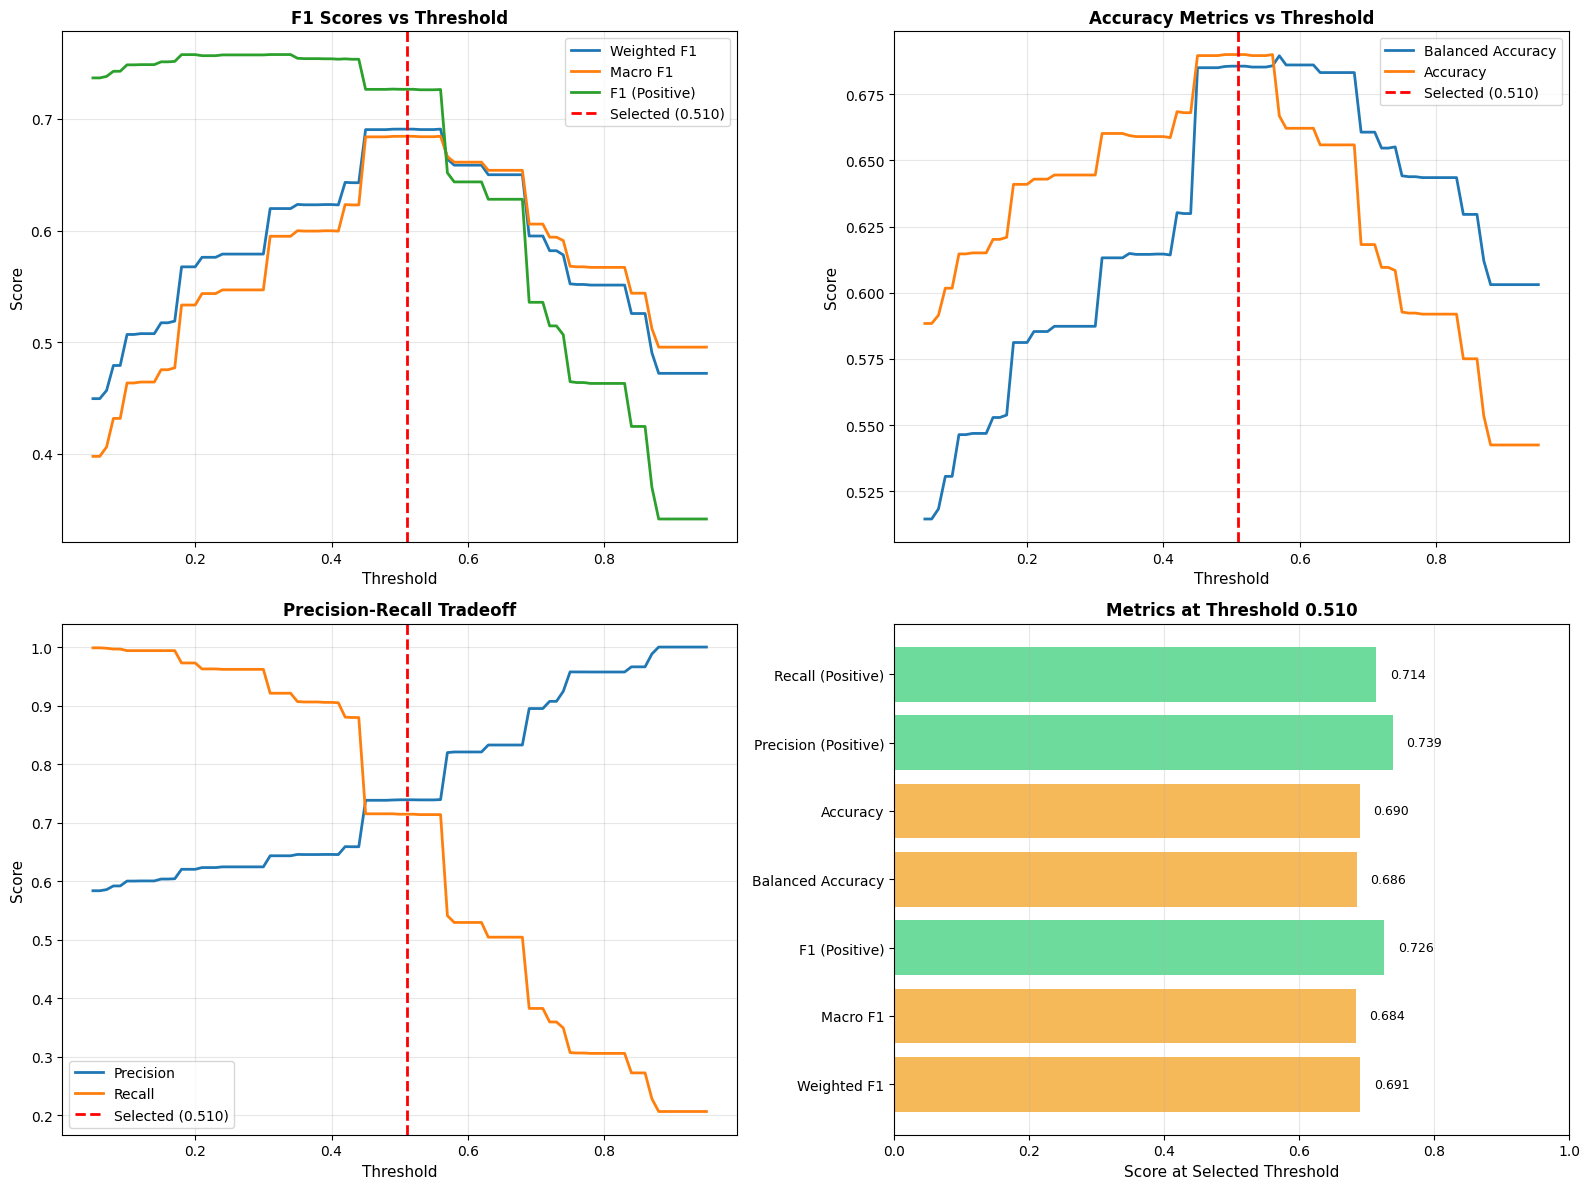


RECOMMENDATIONS

Based on the analysis:
  - For balanced performance: Use weighted_f1 or macro_f1
  - For equal class importance: Use balanced_accuracy or youden
  - For vulnerability detection focus: Use f1 (but expect more false positives)

Current selection: weighted_f1 with threshold 0.5100

✓ SBERT model saved as clf_sbert
✓ Using weighted_f1 threshold: 0.5100


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, log_loss, brier_score_loss,
    average_precision_score, f1_score
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

class VulnerabilityClassifier:
  
    
    def __init__(self, calibrate=True, threshold_metric='weighted_f1'):
       
        self.calibrate = calibrate
        self.threshold_metric = threshold_metric
        self.model = None
        self.calibrated_model = None
        self.feature_cols = None
        self.optimal_threshold = 0.5
        self.threshold_scores = {}  # Store all threshold options
        
    def load_data(self, filepath):
        
        print("Loading data...")
        df = pd.read_csv(filepath)
        
        
        self.feature_cols = [col for col in df.columns if col.startswith('dim_')]
        print(f"Found {len(self.feature_cols)} embedding dimensions")
        
        X = df[self.feature_cols].values
        y = df['target'].values
        
        
        unique, counts = np.unique(y, return_counts=True)
        print(f"\nClass distribution:")
        for label, count in zip(unique, counts):
            print(f"  Class {label}: {count} ({count/len(y)*100:.2f}%)")
        
        return X, y, df
    
    def train(self, X_train, y_train, X_val=None, y_val=None):
       
        print("\nTraining XGBoost classifier...")
        
        
        unique, counts = np.unique(y_train, return_counts=True)
        if len(unique) == 2:
            scale_pos_weight = counts[0] / counts[1]
            print(f"Using scale_pos_weight: {scale_pos_weight:.2f}")
        else:
            scale_pos_weight = 1
        
        
        params = {
            'objective': 'binary:logistic',
            'eval_metric': 'logloss',
            'max_depth': 6,
            'learning_rate': 0.05,
            'n_estimators': 300,
            'min_child_weight': 3,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'reg_alpha': 0.1,
            'reg_lambda': 1.0,
            'scale_pos_weight': scale_pos_weight,
            'random_state': RANDOM_STATE,
            'n_jobs': -1,
            'tree_method': 'hist',
        }
        
       
        self.model = xgb.XGBClassifier(**params)
        
     
        eval_set = [(X_train, y_train)]
        if X_val is not None and y_val is not None:
            eval_set.append((X_val, y_val))
        
     
        try:
            from xgboost.callback import EarlyStopping
            callbacks = [EarlyStopping(rounds=50, save_best=True)]
            
            self.model.fit(
                X_train, y_train,
                eval_set=eval_set,
                callbacks=callbacks,
                verbose=50
            )
        except (ImportError, TypeError):
            try:
                self.model.fit(
                    X_train, y_train,
                    eval_set=eval_set,
                    early_stopping_rounds=50,
                    verbose=50
                )
            except TypeError:
                print("Warning: Early stopping not available, training without it")
                self.model.fit(
                    X_train, y_train,
                    eval_set=eval_set,
                    verbose=50
                )
        
        print(f"\nTraining completed")
        print(f"Best iteration: {self.model.best_iteration if hasattr(self.model, 'best_iteration') else 'N/A'}")
        
      
        if self.calibrate and X_val is not None and y_val is not None:
            print("\nCalibrating probabilities using isotonic regression...")
            self.calibrated_model = CalibratedClassifierCV(
                self.model, 
                method='isotonic',
                cv='prefit'
            )
            self.calibrated_model.fit(X_val, y_val)
            print("Calibration complete!")
            
        
            print(f"\nFinding optimal threshold using '{self.threshold_metric}' on validation set...")
            self.find_all_optimal_thresholds(X_val, y_val, use_calibrated=True)
        else:
       
            print(f"\nFinding optimal threshold using '{self.threshold_metric}' on training set...")
            self.find_all_optimal_thresholds(X_train, y_train, use_calibrated=False)
        
        print(f"\nTraining complete! Optimal threshold set to: {self.optimal_threshold:.4f}")
        
        return self
    
    def predict_proba(self, X, use_calibrated=None):
       
        if use_calibrated is None:
            use_calibrated = self.calibrate
        
        if use_calibrated and self.calibrated_model is not None:
            return self.calibrated_model.predict_proba(X)[:, 1]
        else:
            return self.model.predict_proba(X)[:, 1]
    
    def predict(self, X, threshold=None, use_calibrated=None):
  
        if threshold is None:
            threshold = self.optimal_threshold
        
        probs = self.predict_proba(X, use_calibrated)
        return (probs >= threshold).astype(int)
    
    def find_all_optimal_thresholds(self, X, y, use_calibrated=None):
       
        from sklearn.metrics import (f1_score, precision_score, recall_score, 
                                     balanced_accuracy_score)
        
        y_probs = self.predict_proba(X, use_calibrated)
        thresholds = np.linspace(0.05, 0.95, 91)
        

        metrics_data = {
            'threshold': [],
            'weighted_f1': [],
            'macro_f1': [],
            'f1_pos': [],
            'balanced_accuracy': [],
            'youden': [],
            'accuracy': [],
            'precision_pos': [],
            'recall_pos': []
        }
        
        for threshold in thresholds:
            y_pred = (y_probs >= threshold).astype(int)
            
            metrics_data['threshold'].append(threshold)
            metrics_data['weighted_f1'].append(
                f1_score(y, y_pred, average='weighted', zero_division=0))
            metrics_data['macro_f1'].append(
                f1_score(y, y_pred, average='macro', zero_division=0))
            metrics_data['f1_pos'].append(
                f1_score(y, y_pred, zero_division=0))
            metrics_data['balanced_accuracy'].append(
                balanced_accuracy_score(y, y_pred))
            
         
            cm = confusion_matrix(y, y_pred)
            if cm.shape == (2, 2):
                tn, fp, fn, tp = cm.ravel()
                tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
                tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
                metrics_data['youden'].append(tpr + tnr - 1)
            else:
                metrics_data['youden'].append(0)
            
            metrics_data['accuracy'].append((y == y_pred).mean())
            metrics_data['precision_pos'].append(
                precision_score(y, y_pred, zero_division=0))
            metrics_data['recall_pos'].append(
                recall_score(y, y_pred, zero_division=0))
        
     
        self.threshold_scores = {}
        for metric in ['weighted_f1', 'macro_f1', 'f1_pos', 'balanced_accuracy', 
                      'youden', 'accuracy']:
            optimal_idx = np.argmax(metrics_data[metric])
            self.threshold_scores[metric] = {
                'threshold': metrics_data['threshold'][optimal_idx],
                'score': metrics_data[metric][optimal_idx]
            }
        

        if self.threshold_metric == 'f1':
            self.optimal_threshold = self.threshold_scores['f1_pos']['threshold']
        else:
            self.optimal_threshold = self.threshold_scores[self.threshold_metric]['threshold']
        
     
        print("\n" + "="*80)
        print("THRESHOLD OPTIMIZATION RESULTS")
        print("="*80)
        print(f"\n{'Metric':<25} {'Optimal Threshold':<20} {'Score':<10}")
        print("-" * 80)
        for metric, data in self.threshold_scores.items():
            marker = " ← SELECTED" if (
                (metric == self.threshold_metric) or 
                (metric == 'f1_pos' and self.threshold_metric == 'f1')
            ) else ""
            print(f"{metric:<25} {data['threshold']:<20.4f} {data['score']:<10.4f}{marker}")
        
        return self.optimal_threshold
    
    def evaluate(self, X, y, use_calibrated=None, threshold=None):
        
        if threshold is None:
            threshold = self.optimal_threshold
        
        print("\n" + "="*80)
        print(f"MODEL EVALUATION (Threshold: {threshold:.4f})")
        print("="*80)
        
      
        y_probs = self.predict_proba(X, use_calibrated)
        y_pred = (y_probs >= threshold).astype(int)
        

        print("\nClassification Report:")
        print(classification_report(y, y_pred, digits=4))
        
        
        print("\nProbability Quality Metrics:")
        print(f"  Log Loss (lower is better):    {log_loss(y, y_probs):.4f}")
        print(f"  Brier Score (lower is better): {brier_score_loss(y, y_probs):.4f}")
        print(f"  ROC-AUC Score:                 {roc_auc_score(y, y_probs):.4f}")
        print(f"  Average Precision Score:       {average_precision_score(y, y_probs):.4f}")
        
       
        from sklearn.metrics import balanced_accuracy_score
        balanced_acc = balanced_accuracy_score(y, y_pred)
        weighted_f1 = f1_score(y, y_pred, average='weighted')
        macro_f1 = f1_score(y, y_pred, average='macro')
        
        print(f"\n  Balanced Accuracy:             {balanced_acc:.4f}")
        print(f"  Weighted F1 Score:             {weighted_f1:.4f}")
        print(f"  Macro F1 Score:                {macro_f1:.4f}")
        
       
        cm = confusion_matrix(y, y_pred)
        print("\nConfusion Matrix:")
        print(cm)
        
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            print(f"  True Negatives:  {tn} ({tn/(tn+fp)*100:.2f}% of actual negatives)")
            print(f"  False Positives: {fp} ({fp/(tn+fp)*100:.2f}% of actual negatives)")
            print(f"  False Negatives: {fn} ({fn/(fn+tp)*100:.2f}% of actual positives)")
            print(f"  True Positives:  {tp} ({tp/(fn+tp)*100:.2f}% of actual positives)")
        
        return {
            'y_true': y,
            'y_pred': y_pred,
            'y_probs': y_probs,
            'threshold': threshold,
            'log_loss': log_loss(y, y_probs),
            'brier_score': brier_score_loss(y, y_probs),
            'roc_auc': roc_auc_score(y, y_probs),
            'avg_precision': average_precision_score(y, y_probs),
            'balanced_accuracy': balanced_acc,
            'weighted_f1': weighted_f1,
            'macro_f1': macro_f1,
            'confusion_matrix': cm
        }
    
    def compare_thresholds(self, X, y, use_calibrated=None):
       
        print("\n" + "="*80)
        print("THRESHOLD COMPARISON ON TEST SET")
        print("="*80)
        
        results = {}
        for metric_name, data in self.threshold_scores.items():
            threshold = data['threshold']
            print(f"\n--- Using {metric_name.upper()} threshold: {threshold:.4f} ---")
            results[metric_name] = self.evaluate(X, y, use_calibrated, threshold)
        
        return results
    
    def plot_threshold_analysis(self, X, y, use_calibrated=None, save_path=None):
     
        from sklearn.metrics import (f1_score, precision_score, recall_score, 
                                     balanced_accuracy_score)
        
        y_probs = self.predict_proba(X, use_calibrated)
        thresholds = np.linspace(0.05, 0.95, 91)
        
        metrics = {
            'Weighted F1': [],
            'Macro F1': [],
            'F1 (Positive)': [],
            'Balanced Accuracy': [],
            'Accuracy': [],
            'Precision (Positive)': [],
            'Recall (Positive)': []
        }
        
        for threshold in thresholds:
            y_pred = (y_probs >= threshold).astype(int)
            metrics['Weighted F1'].append(f1_score(y, y_pred, average='weighted', zero_division=0))
            metrics['Macro F1'].append(f1_score(y, y_pred, average='macro', zero_division=0))
            metrics['F1 (Positive)'].append(f1_score(y, y_pred, zero_division=0))
            metrics['Balanced Accuracy'].append(balanced_accuracy_score(y, y_pred))
            metrics['Accuracy'].append((y == y_pred).mean())
            metrics['Precision (Positive)'].append(precision_score(y, y_pred, zero_division=0))
            metrics['Recall (Positive)'].append(recall_score(y, y_pred, zero_division=0))
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
      
        ax = axes[0, 0]
        ax.plot(thresholds, metrics['Weighted F1'], label='Weighted F1', linewidth=2)
        ax.plot(thresholds, metrics['Macro F1'], label='Macro F1', linewidth=2)
        ax.plot(thresholds, metrics['F1 (Positive)'], label='F1 (Positive)', linewidth=2)
        ax.axvline(x=self.optimal_threshold, color='red', linestyle='--', 
                  linewidth=2, label=f'Selected ({self.optimal_threshold:.3f})')
        ax.set_xlabel('Threshold', fontsize=11)
        ax.set_ylabel('Score', fontsize=11)
        ax.set_title('F1 Scores vs Threshold', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
 
        ax = axes[0, 1]
        ax.plot(thresholds, metrics['Balanced Accuracy'], label='Balanced Accuracy', linewidth=2)
        ax.plot(thresholds, metrics['Accuracy'], label='Accuracy', linewidth=2)
        ax.axvline(x=self.optimal_threshold, color='red', linestyle='--', 
                  linewidth=2, label=f'Selected ({self.optimal_threshold:.3f})')
        ax.set_xlabel('Threshold', fontsize=11)
        ax.set_ylabel('Score', fontsize=11)
        ax.set_title('Accuracy Metrics vs Threshold', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
 
        ax = axes[1, 0]
        ax.plot(thresholds, metrics['Precision (Positive)'], label='Precision', linewidth=2)
        ax.plot(thresholds, metrics['Recall (Positive)'], label='Recall', linewidth=2)
        ax.axvline(x=self.optimal_threshold, color='red', linestyle='--', 
                  linewidth=2, label=f'Selected ({self.optimal_threshold:.3f})')
        ax.set_xlabel('Threshold', fontsize=11)
        ax.set_ylabel('Score', fontsize=11)
        ax.set_title('Precision-Recall Tradeoff', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
   
        ax = axes[1, 1]
        optimal_idx = np.argmin(np.abs(thresholds - self.optimal_threshold))
        metric_names = list(metrics.keys())
        metric_values = [metrics[name][optimal_idx] for name in metric_names]
        
        colors = ['#2ecc71' if v > 0.7 else '#e74c3c' if v < 0.5 else '#f39c12' 
                 for v in metric_values]
        bars = ax.barh(metric_names, metric_values, color=colors, alpha=0.7)
        ax.set_xlabel('Score at Selected Threshold', fontsize=11)
        ax.set_title(f'Metrics at Threshold {self.optimal_threshold:.3f}', 
                    fontsize=12, fontweight='bold')
        ax.set_xlim([0, 1])
        ax.grid(True, alpha=0.3, axis='x')
        
   
        for i, (bar, val) in enumerate(zip(bars, metric_values)):
            ax.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Threshold analysis plot saved to {save_path}")
        plt.show()


def main():
   

    filepath = r"M:\Merged\Application2\ExtractedForParsing\vul_fix_vul_jsonl\sbertembedding_chunks\merged_sbert_embedding_shifts_chunks_noTripleZero.csv"
    
    print("="*80)
    print("XGBoost Probabilistic Classifier for Vulnerability Detection")
    print("IMPROVED VERSION: Balanced Threshold Optimization")
    print("Using SBERT (Sentence-BERT) Embeddings")
    print("="*80)
    
    
    threshold_metric = 'weighted_f1' 
   
    
    print(f"\nUsing threshold metric: {threshold_metric}")

    clf = VulnerabilityClassifier(calibrate=True, threshold_metric=threshold_metric)
    

    X, y, df = clf.load_data(filepath)
    
   
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.176, random_state=RANDOM_STATE, stratify=y_temp
    )
    
    print(f"\nData split:")
    print(f"  Training:   {len(X_train)} samples")
    print(f"  Validation: {len(X_val)} samples")
    print(f"  Test:       {len(X_test)} samples")
    
  
    clf.train(X_train, y_train, X_val, y_val)
    

    print("\n" + "="*80)
    print(f"EVALUATION ON TEST SET (Using {threshold_metric.upper()} threshold)")
    print("="*80)
    
    results = clf.evaluate(X_test, y_test, use_calibrated=True)
    

    comparison_results = clf.compare_thresholds(X_test, y_test, use_calibrated=True)
    
 
    print("\n" + "="*80)
    print("GENERATING VISUALIZATIONS")
    print("="*80)
    
    clf.plot_threshold_analysis(X_test, y_test, save_path='threshold_analysis_comprehensive.png')
    
    print("\n" + "="*80)
    print("RECOMMENDATIONS")
    print("="*80)
    print(f"\nBased on the analysis:")
    print(f"  - For balanced performance: Use weighted_f1 or macro_f1")
    print(f"  - For equal class importance: Use balanced_accuracy or youden")
    print(f"  - For vulnerability detection focus: Use f1 (but expect more false positives)")
    print(f"\nCurrent selection: {threshold_metric} with threshold {clf.optimal_threshold:.4f}")
    
    return clf, X_test, y_test, comparison_results


if __name__ == "__main__":
    clf, X_test, y_test, comparison = main()
    
    clf_sbert = clf
    X_test_sbert = X_test
    y_test_shared = y_test
    print(f"\n✓ SBERT model saved as clf_sbert")
    print(f"✓ Using {clf.threshold_metric} threshold: {clf.optimal_threshold:.4f}")